<a name='0'></a>

# **Phase 1 — Load, Explore & Clean**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("https://raw.githubusercontent.com/Sultandev1/dataset/refs/heads/main/insurance.csv")

## 1.Explore

Let's show the head to get an idea of the dataset

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Now with the Shape

In [ ]:
df.shape

(1338, 7)

Now Lets see the Columns and its Dtypes

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


We have 1 column in the wrong type "smoker"

Let's Check if there is any missing values

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Great! no missing values found

In [ ]:
df.duplicated().sum()

np.int64(1)

We have 1 duplicated row

And lastly Let's check for the outliners

Text(0, 0.5, 'Charges')

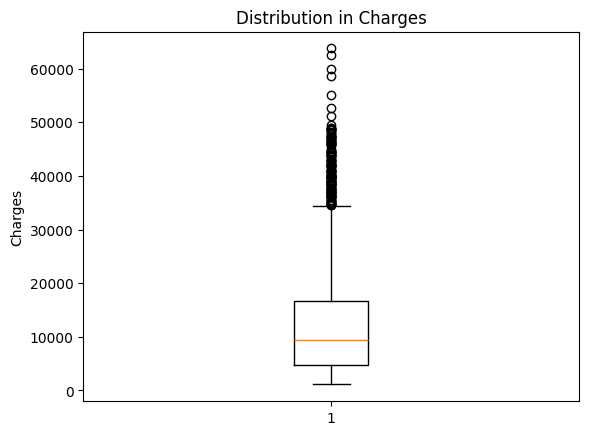

In [ ]:
plt.boxplot(df["charges"]) # to show Distribution in charges
plt.title("Distribution in Charges")
plt.ylabel("Charges")

###conclusion:


*   The df dosent have any null values
*   There is one wrong column "smoker"
*   and just 1 row duplicated



Now Lets apply the cleaning stage

In [ ]:
def clean_data(df):
  """This function applies the cleaning methods to the dataframe"""
  # Create a copy so the main df stays the same and get upadted df
  df_clean = df.copy()
  # Createing a mapping dic to replace the str column
  df_clean['smoker'] =  df_clean['smoker'].apply(lambda x: True if x == "yes" else False)
  # dropping that 1 row..
  df_clean = df_clean.drop_duplicates(keep="first")
  #Capping Values at 99th percentile
  up_limit = df_clean['charges'].quantile(0.99)
  #Applying limit
  df_clean['charges'] = np.where(df_clean['charges'] > up_limit, up_limit,df_clean['charges'])
  if df_clean.isnull().sum().sum() != 0: # 1st check: Checking if there is missing values in the df
    raise Exception("missing val")
  elif (df_clean['charges'] <= 0).sum().sum() != 0: #2nd check: Checking if there is wrong values
    raise Exception("Zero or negataive in non negative coulmn")
  elif len(df_clean.columns) != 7: #3rd check: Checking if there is missing columns
    raise Exception("missing cols")
  return df_clean
df_cleaned = clean_data(df) #Calling the function
df_cleaned.to_csv("clean_data.csv")

# That's it for Phase 1!

# [BACK TO TOP](#0)